In [32]:
import os
import json

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

In [2]:
data_path = "/Users/rito4ka/dev/diploma/data/mvp_annotations"

In [68]:
def parse_stats(split):
    characteristics = {
        "smaller_dims": [],
        "bigger_dims": [],
        "areas": [], 
        "materials": [],
        "categories": [],
    }
    
    files = os.listdir(f"{data_path}/{split}2017")

    for file in files:
        with open(f"{data_path}/{split}2017/{file}", "r") as file:
            data = json.load(file)
            for item in data["annotations"]:
                x, y, w, h = item["bbox"]
                w, h = int(w), int(h)
                characteristics["smaller_dims"].append(min(w, h))
                characteristics["bigger_dims"].append(max(w, h))
                characteristics["areas"].append(w * h)
                characteristics["materials"].append(item["material"])
                characteristics["categories"].append(item["category"])

    return pd.DataFrame(characteristics)


def draw_distributions(df, savepath="./out"):
    if not os.path.exists(savepath):
        os.mkdir(savepath)

    df_corr = df.copy()
    df_corr["categories"] = pd.factorize(df["categories"])[0]
    df_corr["materials"] = pd.factorize(df["materials"])[0]
    df_corr.drop(["smaller_dims", "bigger_dims"], axis=1, inplace=True)
    
    plt.figure(figsize=(10, 8))
    corr = df_corr.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="Spectral", center=0, 
                annot_kws={"size": 10}, fmt=".3f")
    plt.title("Correlation Matrix of All Variables")
    plt.tight_layout()
    plt.savefig(f"{savepath}/corr.png")

    plt.figure(figsize=(10, 6))
    sns.histplot(df["areas"], bins=20, kde=True)
    plt.title("Distribution of Picture Sizes")
    plt.xlabel("Picture Size (Area)")
    plt.ylabel("Frequency")
    plt.savefig(f"{savepath}/areas_distro.png")
    
    plt.figure(figsize=(10, 20))
    sns.countplot(data=df, y="categories", order=df["categories"].value_counts().index)
    plt.title("Distribution of Categories")
    plt.xlabel("Count")
    plt.ylabel("Category")
    plt.savefig(f"{savepath}/categories_distro.png")
    
    plt.figure(figsize=(10, 20))
    sns.countplot(data=df, y="materials", order=df["materials"].value_counts().index)
    plt.title("Distribution of Materials")
    plt.xlabel("Count")
    plt.ylabel("Material")
    plt.savefig(f"{savepath}/materials_distro.png")

In [58]:
val_stats = parse_stats("val")
val_stats.describe()

,smaller_dims,bigger_dims,areas
count,50672.000000,50672.000000,50672.000000
mean,48.997257,85.403201,10449.767150
std,67.088711,107.179833,30664.385997
min,0.000000,0.000000,0.000000
25%,11.000000,22.000000,255.000000
50%,25.000000,45.000000,1080.000000
75%,56.000000,102.000000,5472.000000
max,640.000000,640.000000,409600.000000


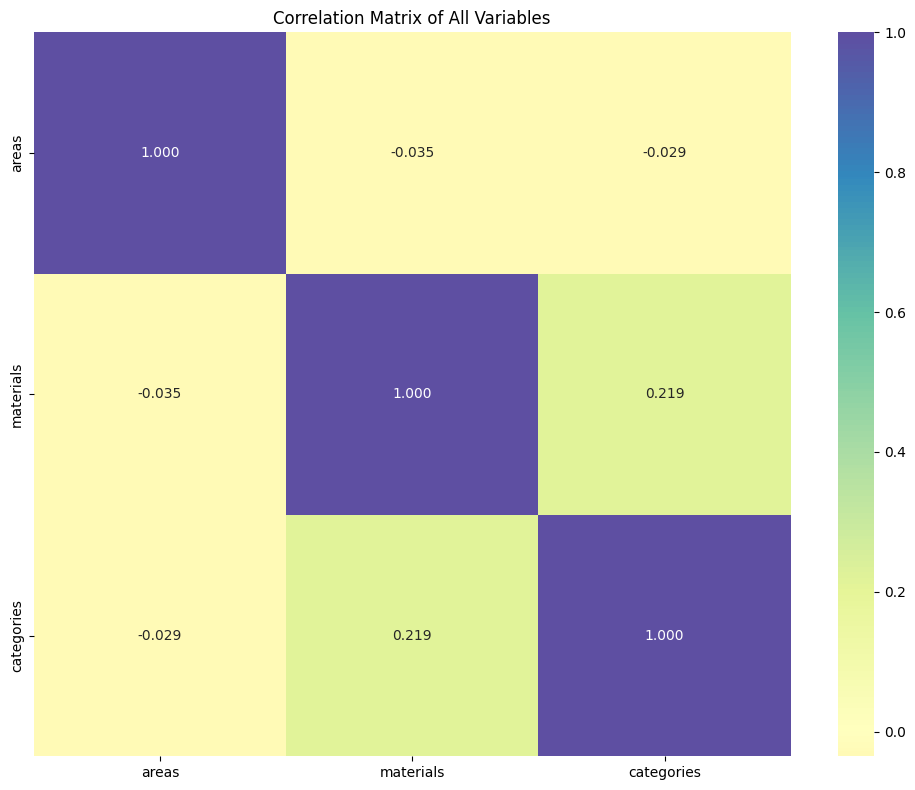

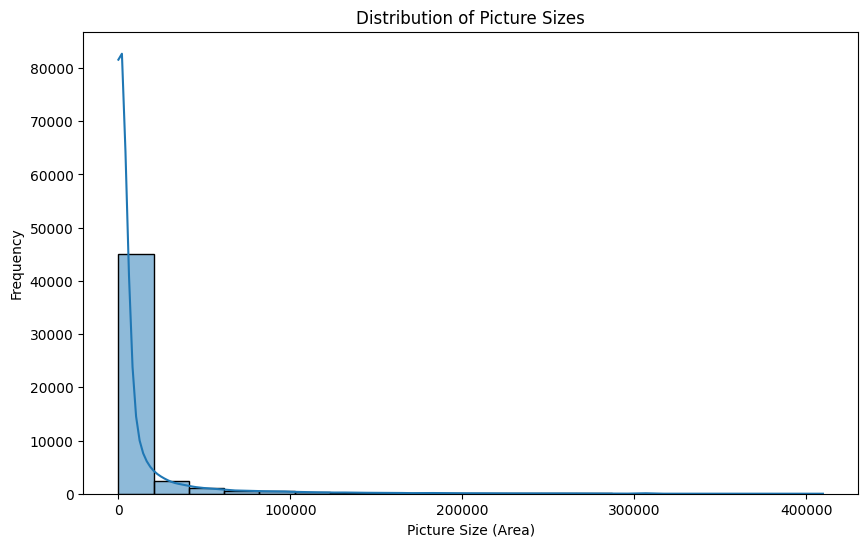

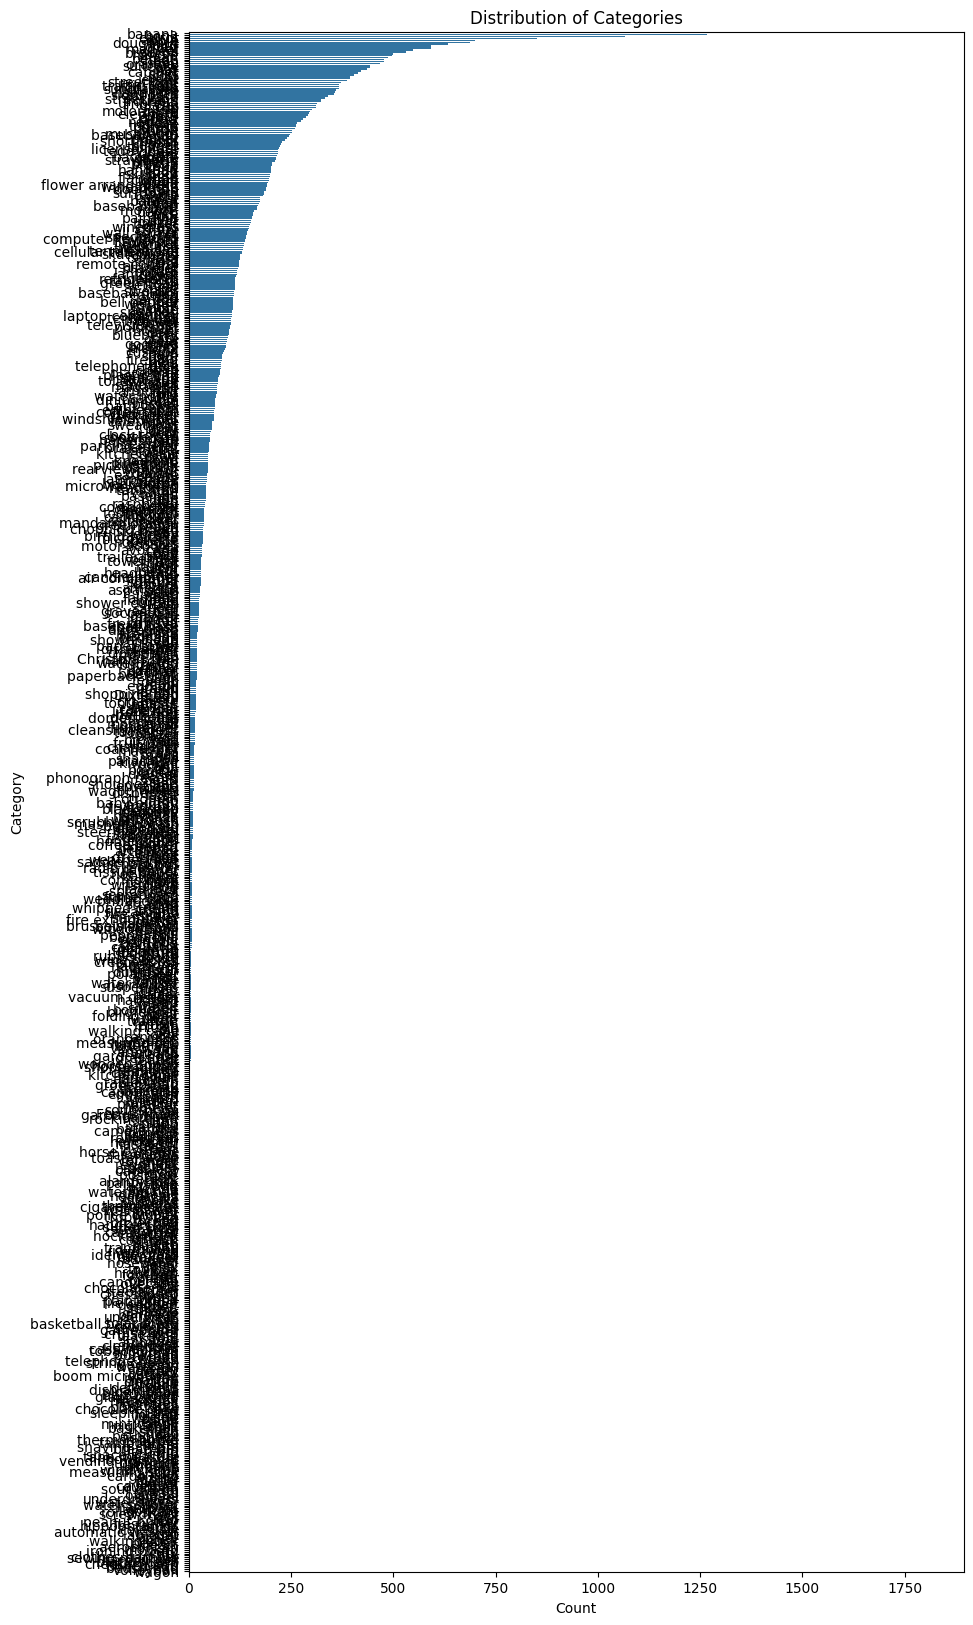

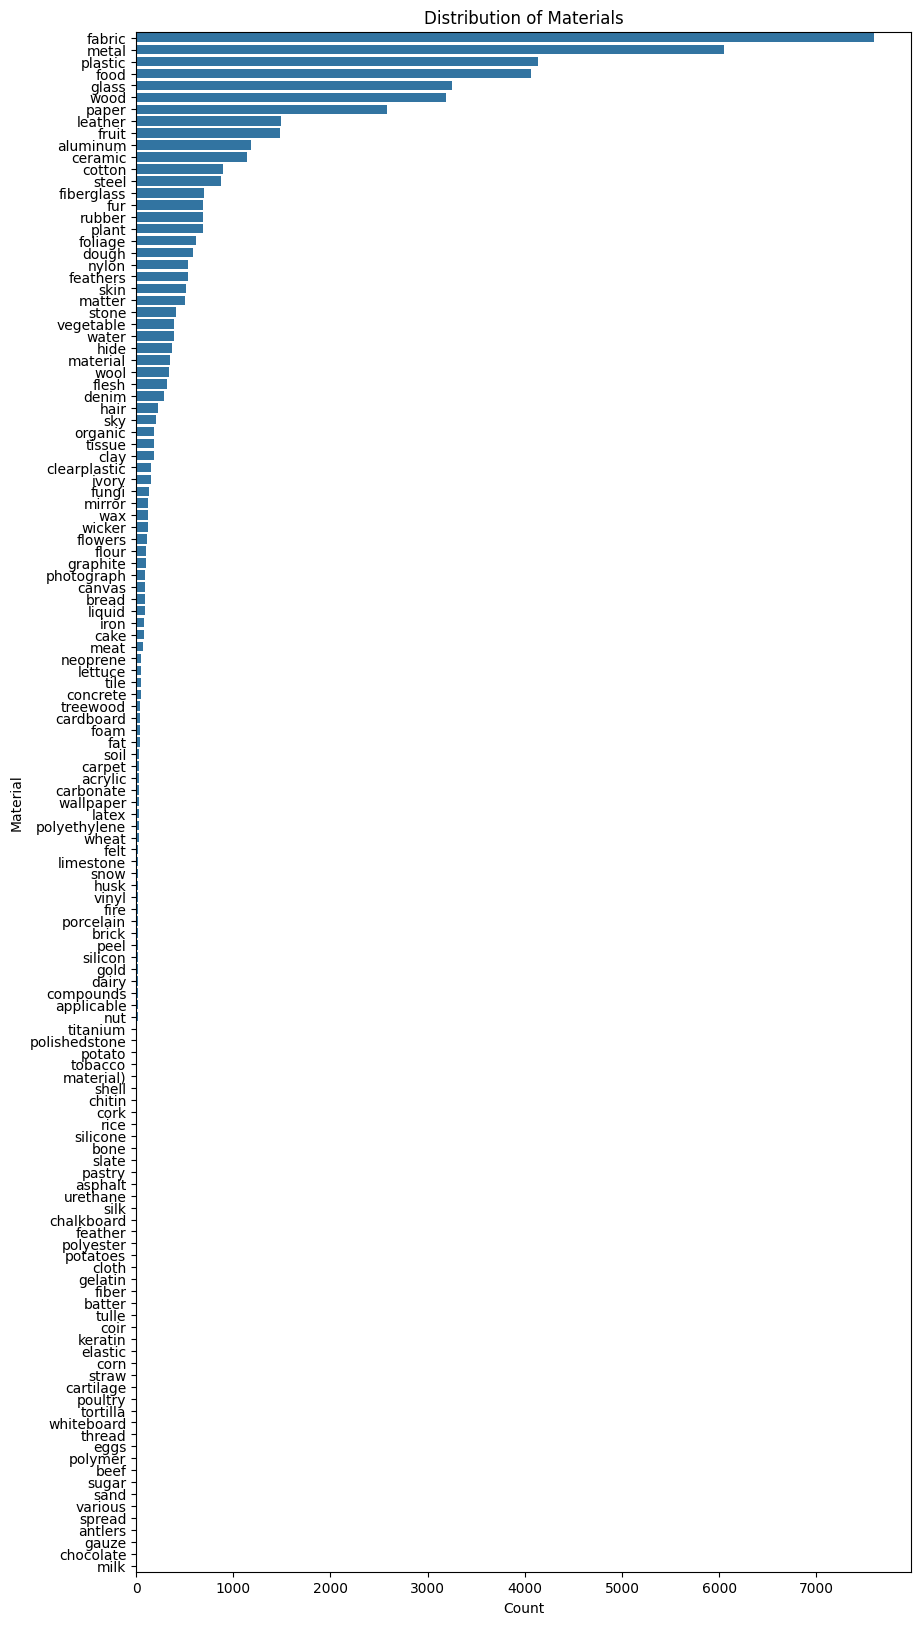

In [69]:
draw_distributions(val_stats, "./val")

In [60]:
train_stats = parse_stats("train")
train_stats.describe()

,smaller_dims,bigger_dims,areas
count,1.270141e+06,1.270141e+06,1.270141e+06
mean,4.442340e+01,7.845761e+01,9.160685e+03
std,6.376621e+01,1.026512e+02,2.877334e+04
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+01,1.800000e+01,1.840000e+02
50%,2.200000e+01,4.100000e+01,8.580000e+02
75%,5.000000e+01,9.200000e+01,4.368000e+03
max,6.400000e+02,6.400000e+02,4.096000e+05


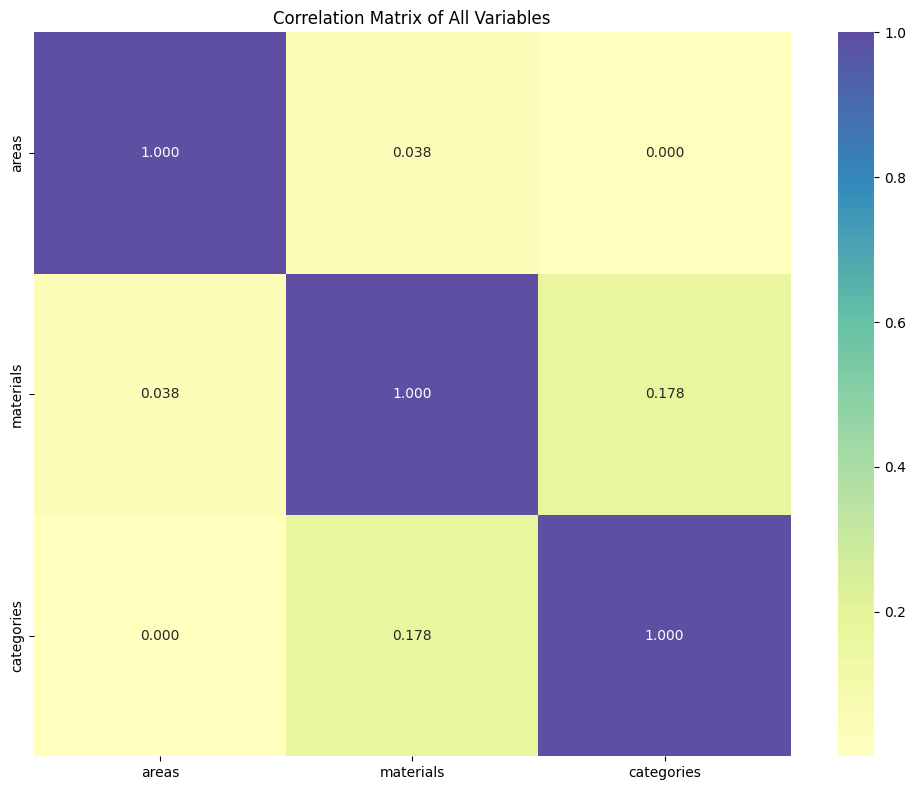

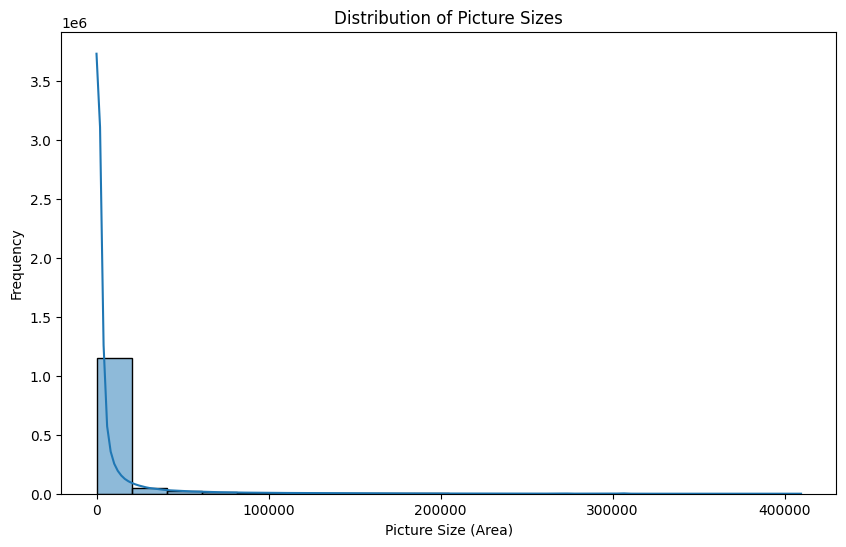

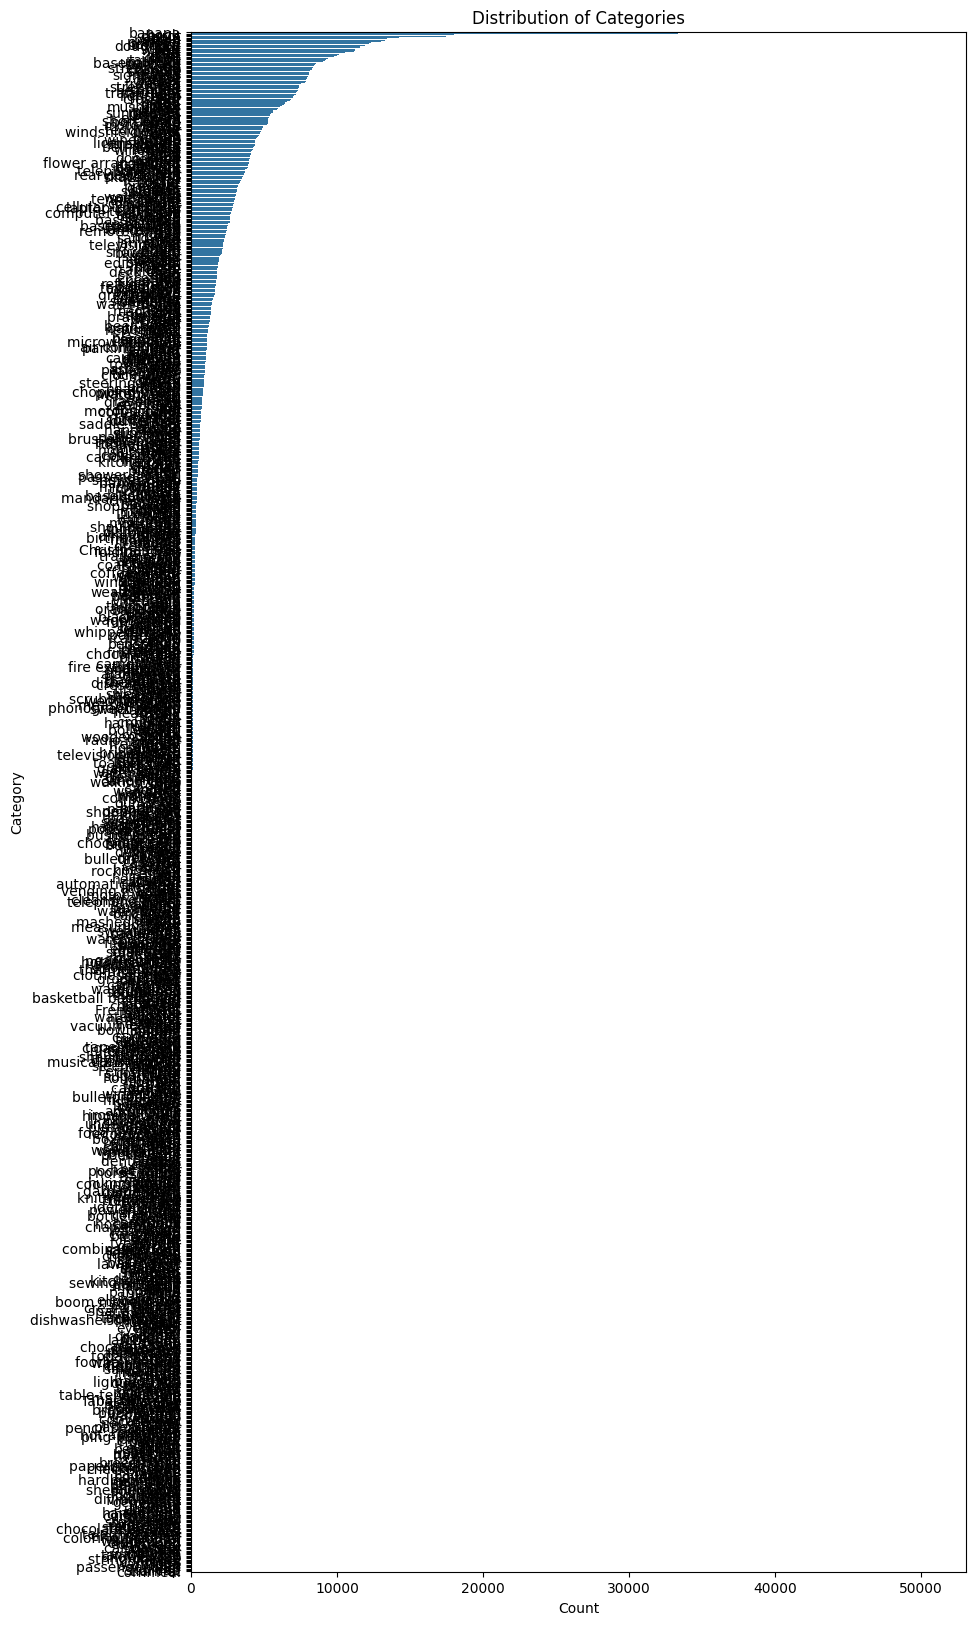

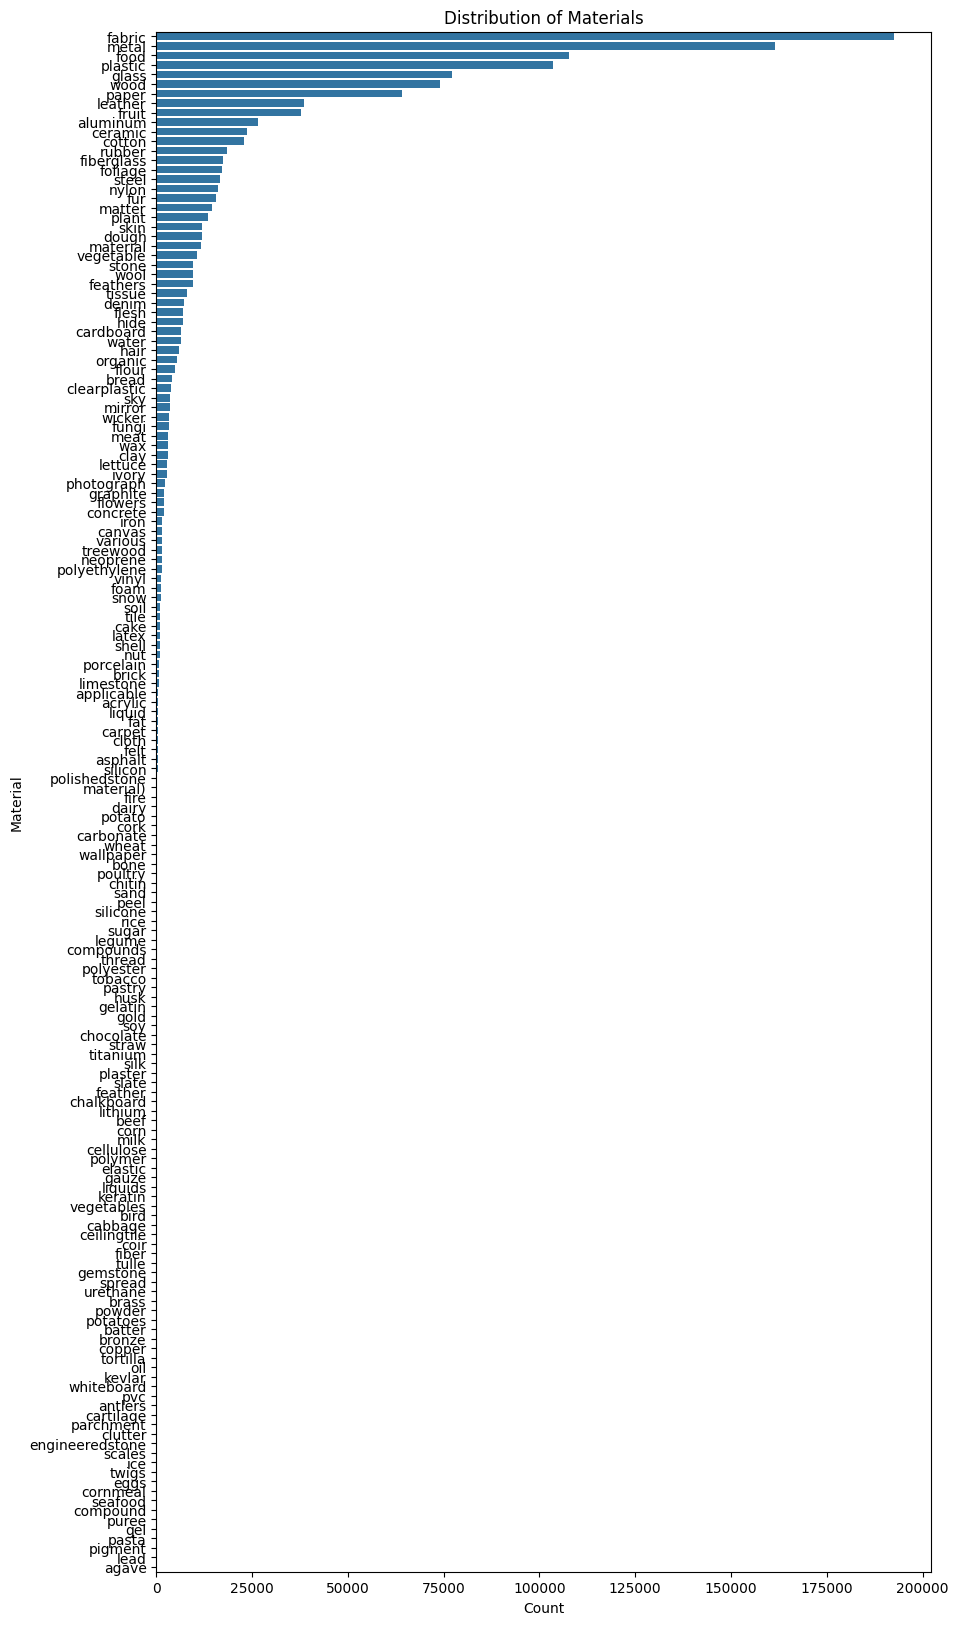

In [70]:
draw_distributions(train_stats, "./train")